Denna notebook används för undersökning av veckodagseffekter inom Extreme Value Theory (EVT) för svenska aktieavkastningar med hjälp av GPD-skattningar samt statistiska mått.

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import EVTLibrary as evt
importlib.reload(evt)
from scipy import stats
from scipy.stats import genpareto
import matplotlib.patches as mpatches

In [7]:
u_prel = [0.041, 0.035, 0.042, 0.035, 0.045, 0.044, 0.046, 0.045, 0.040, 0.037]
loss_df = evt.get_data(start="2000-01-01", end="2026-03-31")
u, extreme_values = evt.get_extreme_data(u_prel, loss_df, False)

Skapa en funktion som delar in datan i två veckogrupper, mån-tis samt ons-fre. Detta är för att undersöka ifall helgen (stängd handel) har någon effekt på våra GDP-skattningar och om de skiljer sig åt i frekvens. 

In [8]:
def split_into_week_groups(df):
    temp = df.copy()

    temp["Weekday"] = temp.index.day_name()

    groups = {
        "mån-tis": ["Monday", "Tuesday"],
        "ons-fre": ["Wednesday", "Thursday", "Friday"]
    }

    result = {}
    for group_name, days in groups.items():
        result[group_name] = temp[temp["Weekday"].isin(days)].copy()

    return result

### Visualisering av log-avkastningen mellan 2000-01-01 till 2026-03-31 för aktien Investor B. 

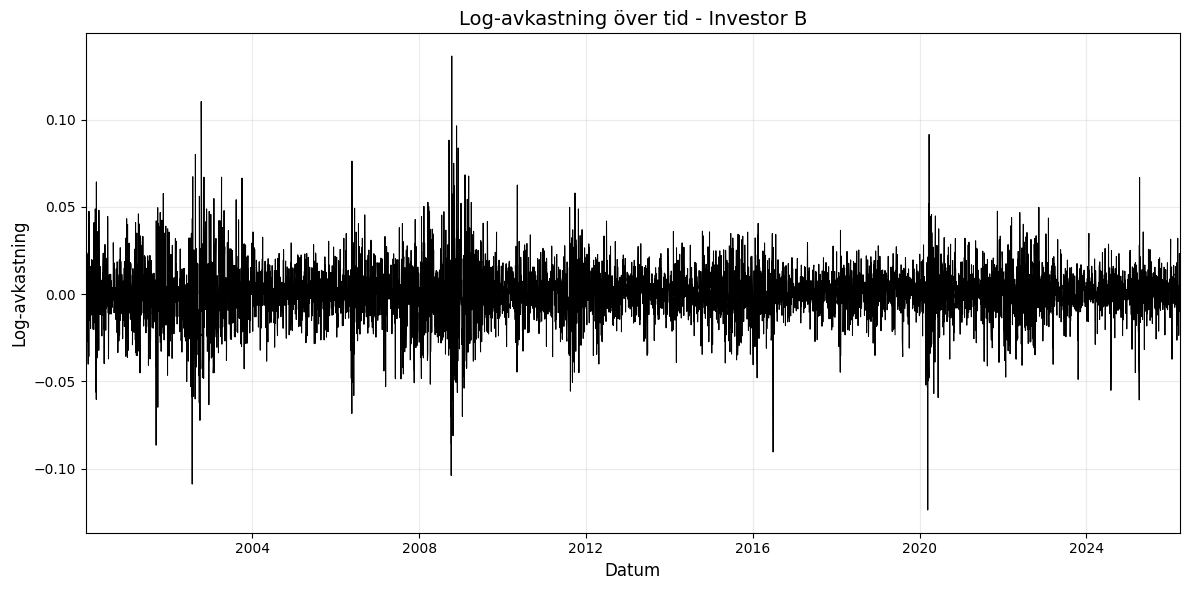

In [9]:
df = yf.download("INVE-B.ST", start="2000-01-01", end="2026-03-31", interval="1d", auto_adjust=True, progress=False)

df_clean = df[df["Volume"] > 0].copy()
df_clean["lgr"] = np.log(df["Close"]).diff()

series = df_clean["lgr"]
plt.figure(figsize=(12, 6))
plt.plot(series.index, series.values, linewidth=0.75, color = "black")

plt.title("Log-avkastning över tid - Investor B", fontsize=14)
plt.xlabel("Datum", fontsize = 12)
plt.ylabel("Log-avkastning", fontsize = 12)

plt.xlim(series.index[0], series.index[-1])
plt.grid(True, alpha = 0.25)
plt.tight_layout()
plt.show()

## Extraherar resultat för samtliga aktier

### Tabell för överskridandesannolikhet uppdelat mellan aktier och veckogrupp

In [10]:
cluster_maxima, clustered_exceedances = evt.get_cluster_maxima(u, extreme_values, r=15)

week_groups = ["mån-tis", "ons-fre"]
declustered_by_week_group = {}
total_declustered_by_week_group = {}
total_loss_by_week_group = {}

for stock in loss_df.columns:
    declustered_by_week_group[stock] = split_into_week_groups(cluster_maxima[stock])
    total_declustered_by_week_group[stock] = {group: len(declustered_by_week_group[stock][group]) for group in week_groups}

    loss_by_week_group = split_into_week_groups(loss_df[[stock]].dropna())
    total_loss_by_week_group[stock] = {group: len(loss_by_week_group[group]) for group in week_groups}

total_declustered_by_week_group = pd.DataFrame(total_declustered_by_week_group)
total_loss_by_week_group = pd.DataFrame(total_loss_by_week_group)

declustered_proportions_by_week_group = (total_declustered_by_week_group / total_loss_by_week_group).round(4)


In [11]:
rows = []

alpha = 0.05
m = len(loss_df.columns)  # antal aktier/tester

for stock in loss_df.columns:
    # Antal exceedances i respektive grupp
    K1 = total_declustered_by_week_group[stock]["mån-tis"]
    K2 = total_declustered_by_week_group[stock]["ons-fre"]

    # Totalt antal observationer i respektive grupp
    n1 = total_loss_by_week_group[stock]["mån-tis"]
    n2 = total_loss_by_week_group[stock]["ons-fre"]

    # Exceedance rates
    lambda1 = K1 / n1
    lambda2 = K2 / n2

    # Poolad proportion under H0
    lambda_pooled = (K1 + K2) / (n1 + n2)

    # Standard error för tvåproportioners z-test
    pooled_variance = lambda_pooled * (1 - lambda_pooled) * ((1 / n1) + (1 / n2))
    se = np.sqrt(pooled_variance)

    z_stat = (lambda1 - lambda2) / se
    pval = stats.norm.sf(abs(z_stat)) * 2

    rows.append({
        "Aktie": stock,
        "K mån-tis": K1,
        "n mån-tis": n1,
        "Frekvens mån-tis": lambda1,
        "K ons-fre": K2,
        "n ons-fre": n2,
        "Frekvens ons-fre": lambda2,
        "Skillnad": lambda1 - lambda2,
        "SE": se,
        "z-stat": z_stat,
        "p-värde": pval,
        "Signifikant": pval < alpha,
        "Signifikant Bonferroni": pval < alpha / m
    })

ztest_table = pd.DataFrame(rows)

display(ztest_table)

,Aktie,K mån-tis,n mån-tis,Frekvens mån-tis,K ons-fre,n ons-fre,Frekvens ons-fre,Skillnad,SE,z-stat,p-värde,Signifikant,Signifikant Bonferroni
0,Kinnevik B,38,2472,0.015372,51,3684,0.013844,0.001529,0.003103,0.492518,0.622353,False,False
1,Investor B,32,2472,0.012945,25,3684,0.006786,0.006159,0.002490,2.473253,0.013389,True,False
2,SEB A,24,2472,0.009709,44,3684,0.011944,-0.002235,0.002717,-0.822395,0.410852,False,False
3,Nordea Bank,28,2472,0.011327,48,3684,0.013029,-0.001702,0.002871,-0.592994,0.553185,False,False
4,Castellum,29,2472,0.011731,22,3684,0.005972,0.005760,0.002357,2.443990,0.014526,True,False
5,Skanska B,18,2472,0.007282,44,3684,0.011944,-0.004662,0.002596,-1.795797,0.072527,False,False
6,ABB,20,2472,0.008091,32,3684,0.008686,-0.000596,0.002379,-0.250309,0.802349,False,False
7,Atlas Copco A,29,2472,0.011731,30,3684,0.008143,0.003588,0.002533,1.416479,0.156635,False,False
8,Boliden,59,2472,0.023867,72,3684,0.019544,0.004323,0.003752,1.152228,0.249227,False,False
9,SCA B,25,2472,0.010113,35,3684,0.009501,0.000613,0.002554,0.239884,0.810420,False,False


In [12]:
week_groups = ["mån-tis", "ons-fre"]

gpd_dict = {}
excesses = {}
rows = []

for stock in loss_df.columns:
    gpd_dict[stock] = {}
    excesses[stock] = {}

    for group in week_groups:
        y = (declustered_by_week_group[stock][group]["Loss"] - u[stock]).dropna()

        excesses[stock][group] = y
        xi_hat, loc_hat, sigma_hat = stats.genpareto.fit(y, floc=0)
        gpd_dict[stock][group] = (xi_hat, loc_hat, sigma_hat)

        rows.append({
            "Aktie": stock,
            "Grupp": group,
            "n": len(y),
            "xi_hat": xi_hat,
            "sigma_hat": sigma_hat
        })

gpd_table = pd.DataFrame(rows)

gpd_wide = gpd_table.pivot(
    index="Aktie",
    columns="Grupp",
    values=["n", "xi_hat", "sigma_hat"]
)

gpd_wide = gpd_wide.swaplevel(axis=1).sort_index(axis=1)
display(gpd_wide)

Grupp         mån-tis                     ons-fre                    
                    n sigma_hat    xi_hat       n sigma_hat    xi_hat
Aktie                                                                
ABB              20.0  0.018638  0.606687    32.0  0.014621  0.483033
Atlas Copco A    29.0  0.020696 -0.079212    30.0  0.024566 -0.104412
Boliden          59.0  0.020356  0.168546    72.0  0.017000  0.458389
Castellum        29.0  0.018242 -0.043637    22.0  0.013925  0.117037
Investor B       32.0  0.010000  0.135928    25.0  0.013914  0.276698
Kinnevik B       38.0  0.019690  0.260303    51.0  0.028953  0.153080
Nordea Bank      28.0  0.022516 -0.033230    48.0  0.018608  0.072667
SCA B            25.0  0.008011  0.459694    35.0  0.014921  0.104728
SEB A            24.0  0.022339  0.278900    44.0  0.012112  0.431456
Skanska B        18.0  0.017682 -0.049767    44.0  0.014752  0.381996

### GPD-anpassning för de olika grupperna. OBS! För många aktier finns inte tillräckligt med data för rättvis inferens. 

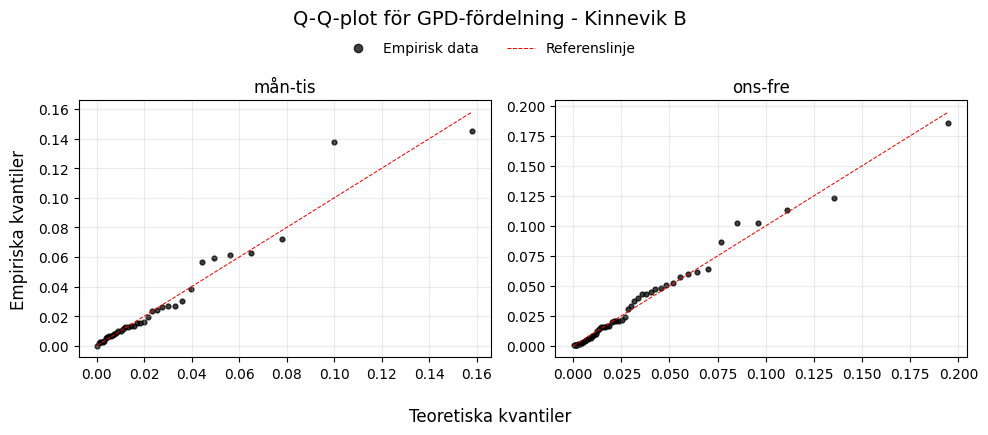

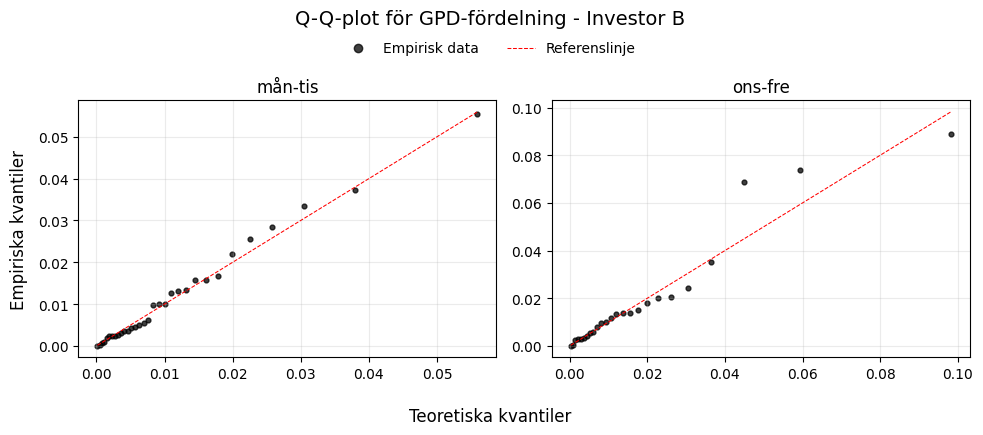

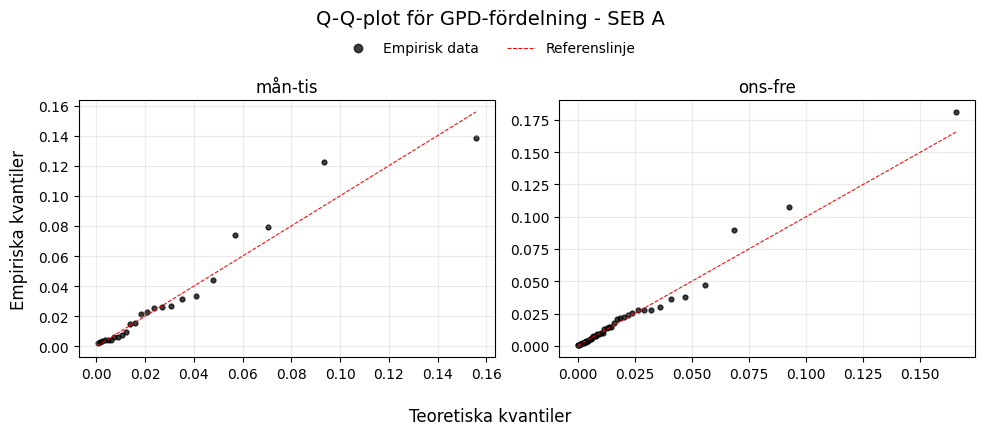

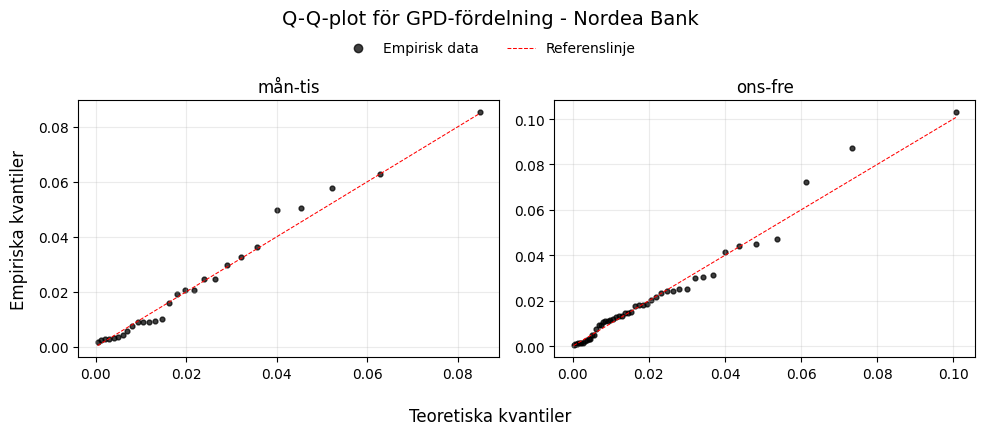

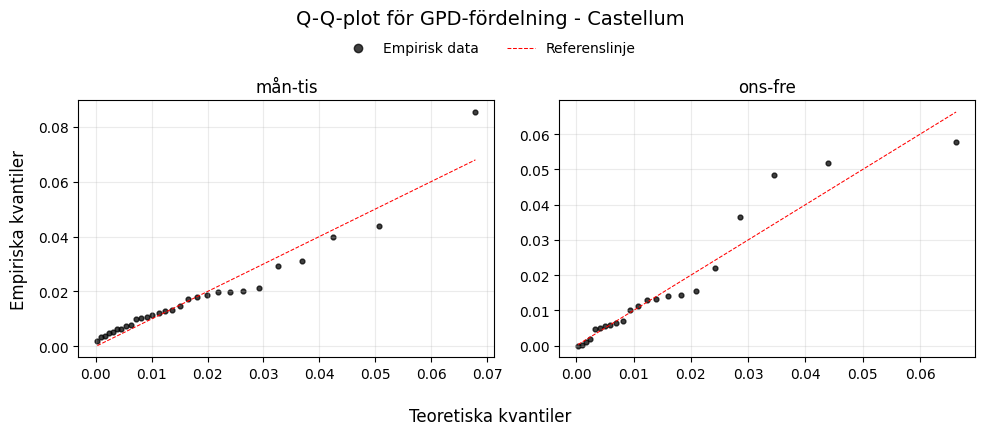

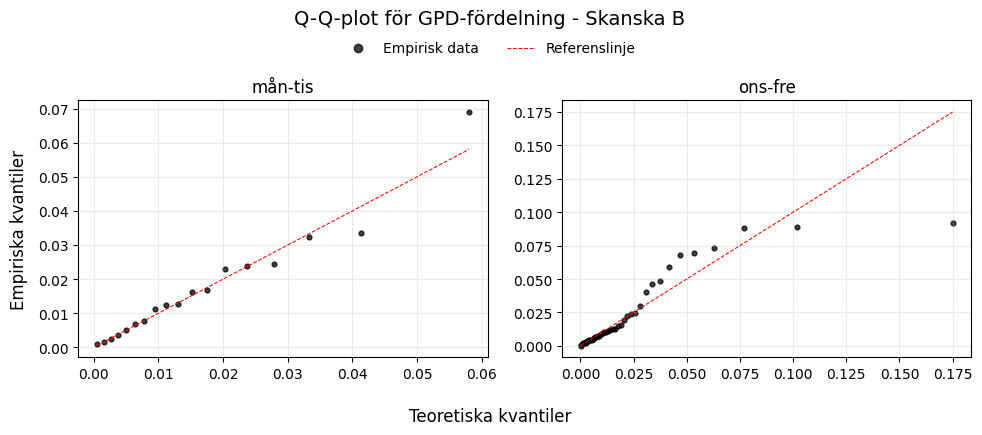

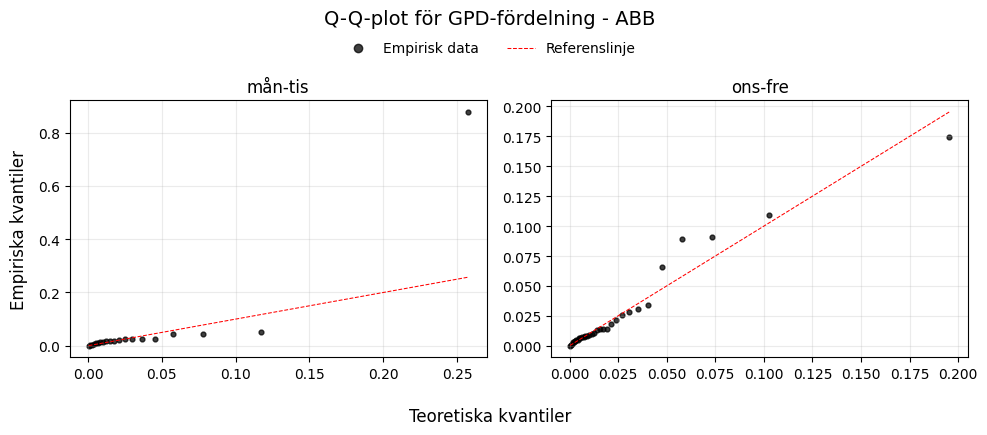

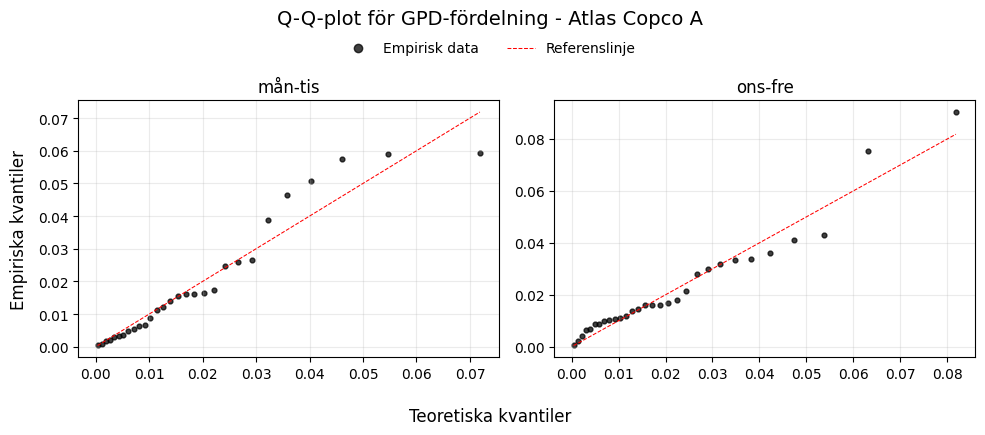

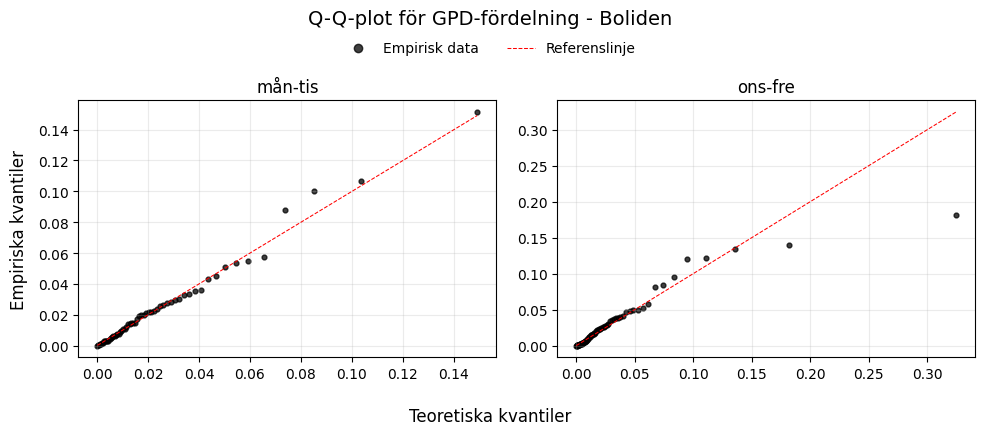

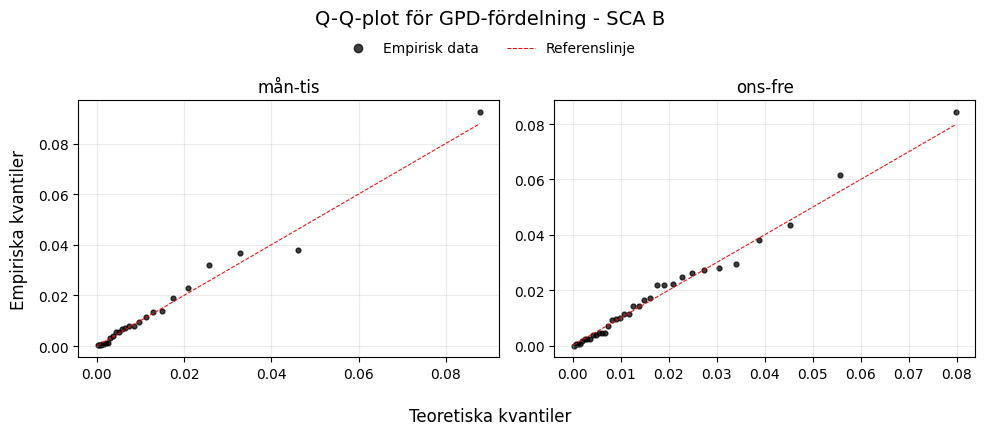

In [13]:
for stock in loss_df.columns:

    ncols = min(2, len(week_groups))
    nrows = int(np.ceil(len(week_groups) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, group in enumerate(week_groups):
        ax = axes[i]

        data = np.asarray(excesses[stock][group], dtype=float)
        sorted_data = np.sort(data)

        n = len(sorted_data)

        xi = gpd_dict[stock][group][0]
        sigma = gpd_dict[stock][group][2]

        p = (np.arange(1, n + 1) - 0.5) / n
        theoretical_q = stats.genpareto.ppf(p, c=xi, loc=0, scale=sigma)

        ax.scatter(theoretical_q, sorted_data, s=12, color="black", alpha=0.75)
        ax.plot(theoretical_q, theoretical_q, color="red", linestyle="--", linewidth=0.75)

        ax.set_title(f"{group}", fontsize=12)
        ax.grid(True, alpha=0.25)

    for j in range(len(week_groups), len(axes)):
        fig.delaxes(axes[j])

    handles = [
        plt.Line2D([], [], marker='o', linestyle='None', color='black', alpha=0.75, label="Empirisk data"),
        plt.Line2D([], [], color="red", linestyle="--", label="Referenslinje", linewidth=0.75)
    ]

    fig.legend(handles=handles, loc='upper center',
               bbox_to_anchor=(0.5, 1.00), ncol=2, frameon=False)
    fig.suptitle(f"Q-Q-plot för GPD-fördelning - {stock}", y=1.05, fontsize=14)
    fig.supxlabel("Teoretiska kvantiler", fontsize=12)
    fig.supylabel("Empiriska kvantiler", fontsize=12)

    plt.tight_layout()
    plt.show()

### Undersök eventuella skillnader i återkomstdiagrammen. 

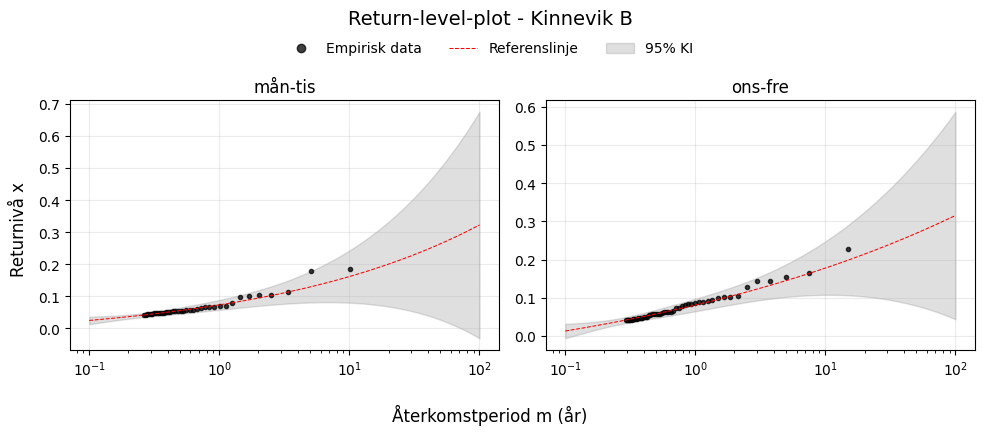

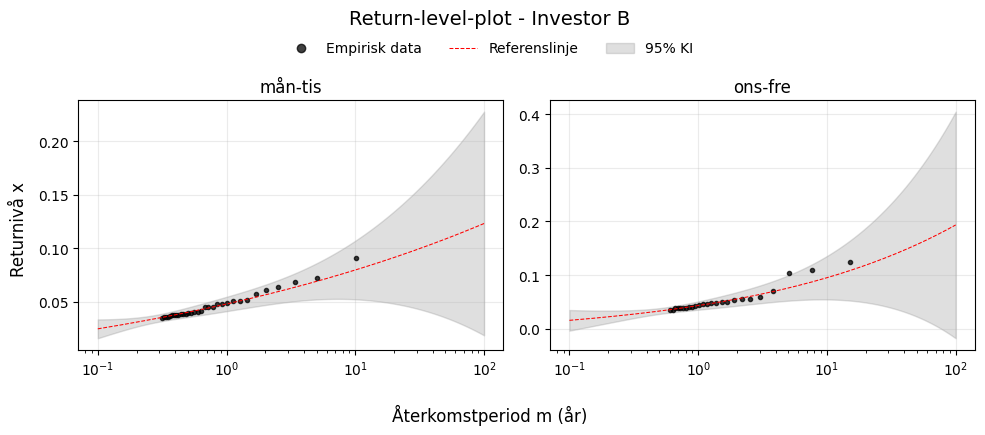

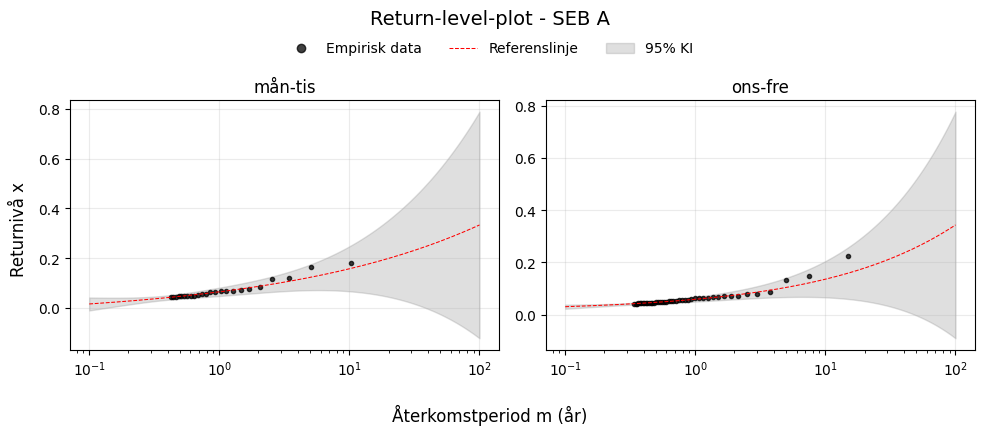

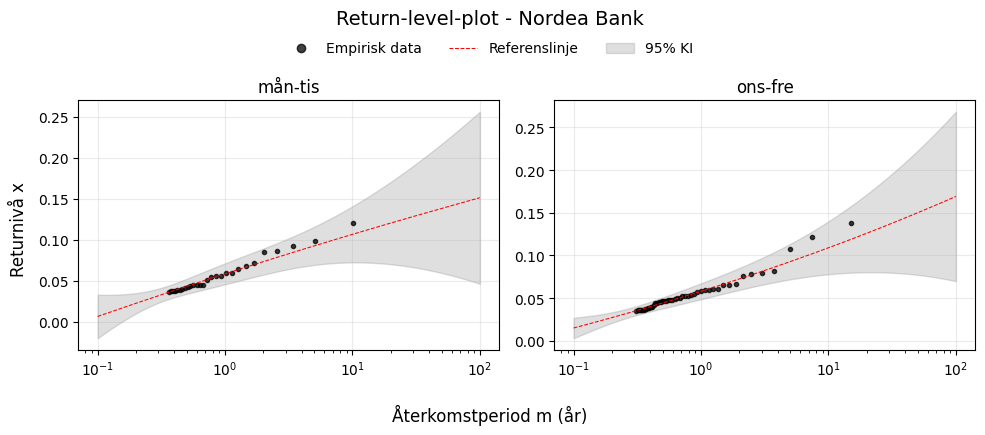

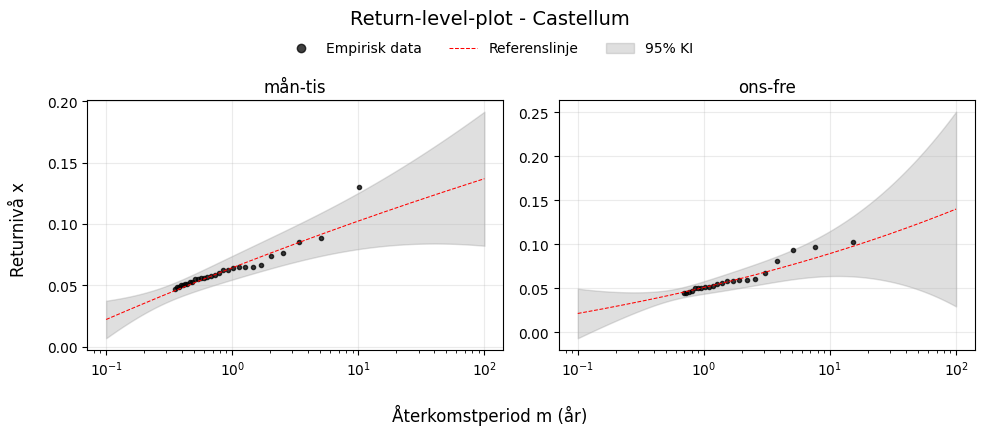

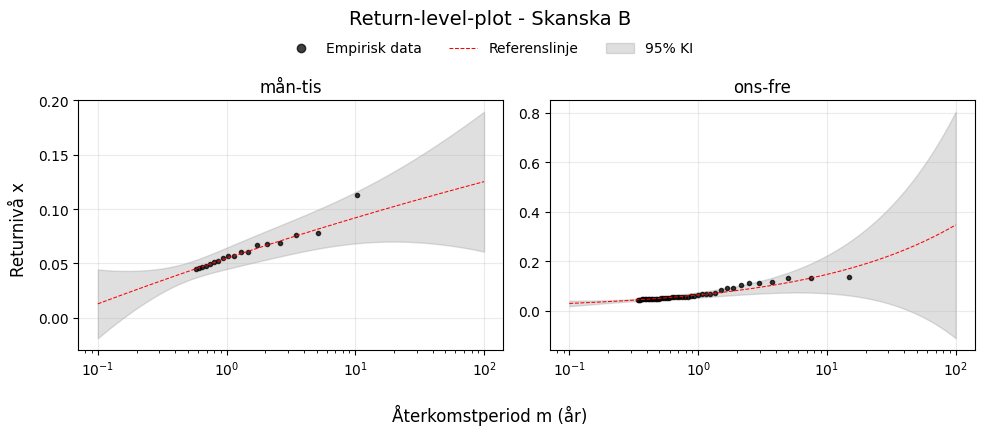

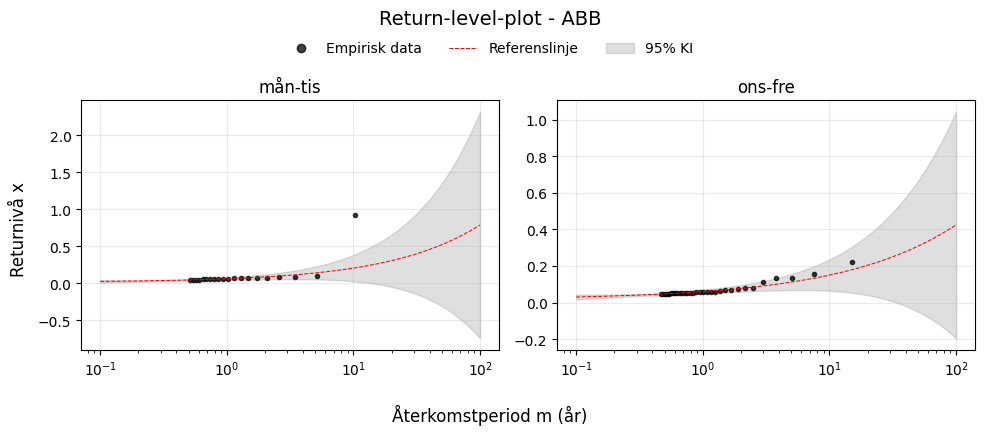

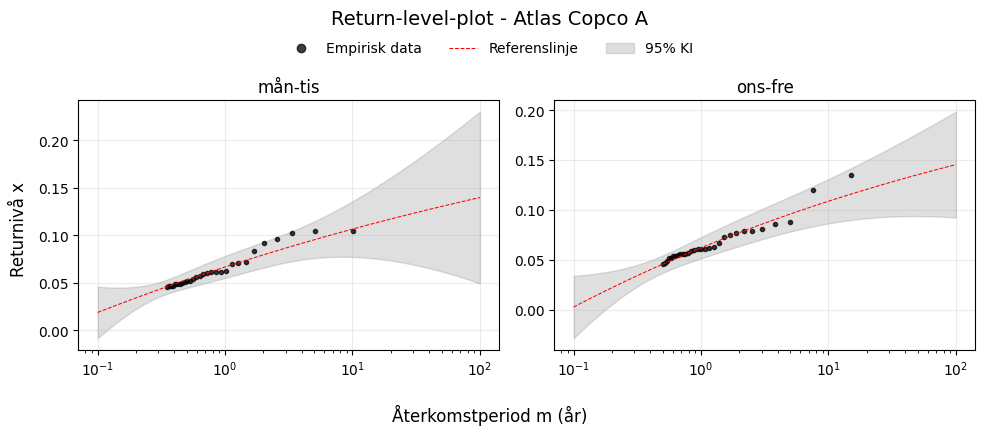

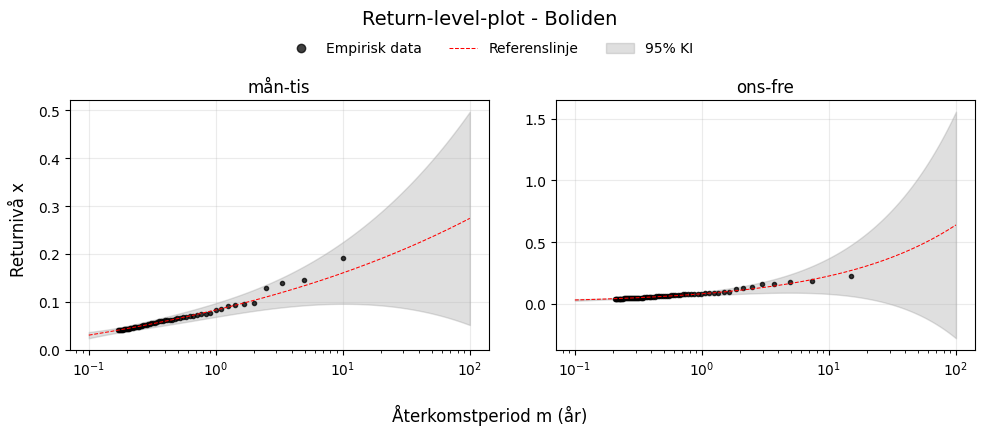

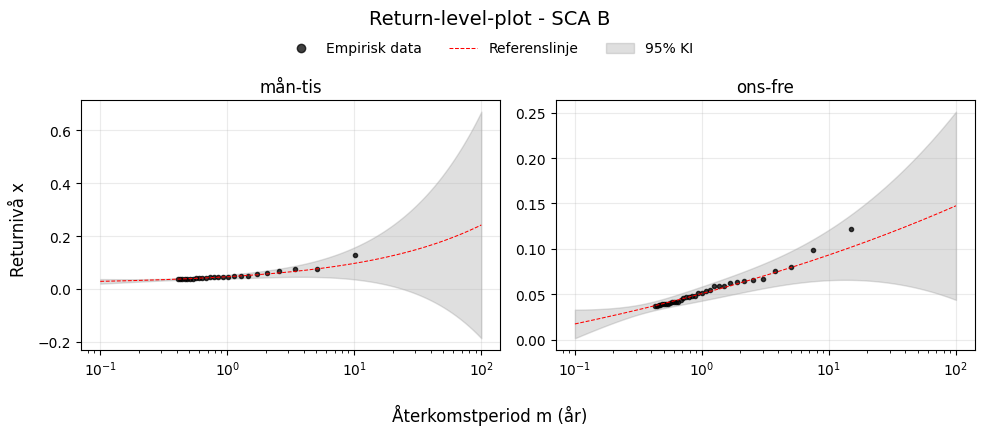

In [14]:
cov_dict = {}

for stock in loss_df.columns:

    cov_dict[stock] = {}

    ncols = min(2, len(week_groups))
    nrows = int(np.ceil(len(week_groups) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, group in enumerate(week_groups):
        ax = axes[i]

        y = excesses[stock][group]
        y_arr = np.asarray(y, dtype=float)

        xi_hat = gpd_dict[stock][group][0]
        sigma_hat = gpd_dict[stock][group][2]

        k_exc = len(y_arr)
        n = total_loss_by_week_group[stock][group]
        rate = k_exc / n

        y_sorted = np.sort(y_arr)
        x_sorted = u[stock] + y_sorted

        ranks = np.arange(1, k_exc + 1)
        p_tail = (k_exc + 1 - ranks) / (k_exc + 1)
        m_emp = 1 / (p_tail * rate)

        ax.semilogx(m_emp / 252, x_sorted, 'o', markersize=3, color="black", alpha=0.75)

        cov_dict[stock][group] = evt.gpd_cov_matrix(y_arr, sigma_hat, xi_hat)

        m_max_years = 100
        m_grid = np.logspace(np.log10(0.1 * 252), np.log10(m_max_years * 252), 200)

        x_th = np.array([evt.return_level_hat(u[stock], sigma_hat, xi_hat, rate, m) for m in m_grid])

        # standard errors
        se = np.array([evt.return_level_se(u[stock], sigma_hat, xi_hat, rate, n, cov_dict[stock][group], m) for m in m_grid])

        ax.semilogx(m_grid / 252, x_th, '--', color = "red", linewidth = 0.75)
        ax.fill_between(m_grid / 252, x_th - 1.96 * se, x_th + 1.96 * se, color="gray", alpha=0.25)

        ax.set_title(f"{group}", fontsize=12)
        ax.grid(True, alpha=0.25)

    for j in range(len(week_groups), len(axes)):
        fig.delaxes(axes[j])

    handles = [
        plt.Line2D([], [], marker='o', linestyle='None', color='black', alpha=0.75, label="Empirisk data"),
        plt.Line2D([], [], color='red', linestyle='--', label="Referenslinje", linewidth=0.75),
        mpatches.Patch(color="gray", alpha=0.25, label="95% KI")
    ]

    fig.legend(handles=handles, loc='upper center',bbox_to_anchor=(0.5, 1.00), ncol=3, frameon=False)
    fig.suptitle(f"Return-level-plot - {stock}", y=1.05, fontsize=14)
    fig.supxlabel("Återkomstperiod m (år)", fontsize=12)
    fig.supylabel("Returnivå x", fontsize=12)

    plt.tight_layout()
    plt.show()